In [341]:
import sqlite3
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score
from math import sqrt
from sklearn import preprocessing
import matplotlib.pyplot as plt
import numpy as np
import os

## Creación de la conexión a la base de datos para leer la tabla "Player Attributes"

In [342]:
ruta = "C:/Users/Alejandro/Documents/database.sqlite"
print(os.path.exists(ruta))

True


In [343]:
cnx = sqlite3.connect("C:\\Users\\Alejandro\\Documents\\database1.sqlite")

In [344]:
df = pd.read_sql_query('SELECT * FROM Player_Attributes', cnx)

In [345]:
df.head()

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0


In [346]:
df.shape

(183978, 42)

In [347]:
df.columns

Index(['id', 'player_fifa_api_id', 'player_api_id', 'date', 'overall_rating',
       'potential', 'preferred_foot', 'attacking_work_rate',
       'defensive_work_rate', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes'],
      dtype='str')

### De todas las columnas determinaremos cuáles se usarán con "feautures" para alimentar al modelo

In [348]:
features = ['potential','crossing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'free_kick_accuracy',
       'long_passing', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes']

### Seleccionamos el target

In [349]:
target = ['overall_rating'] 

### Limpiar los datos eliminando filas con valores nan

In [350]:
df = df.dropna()

### Separamos las features en 'x', y el target en 'y'

In [351]:
X = df[features]
Y = df[target]

### Mostrar el contenido de una fila de conjunto X

In [352]:
X.iloc[2000]

potential             73.0
crossing              69.0
heading_accuracy      55.0
short_passing         63.0
volleys               41.0
dribbling             58.0
free_kick_accuracy    29.0
long_passing          58.0
acceleration          83.0
sprint_speed          71.0
agility               58.0
reactions             54.0
balance               74.0
shot_power            65.0
stamina               74.0
strength              57.0
long_shots            50.0
aggression            57.0
interceptions         57.0
positioning           48.0
vision                42.0
penalties             43.0
marking               67.0
sliding_tackle        65.0
gk_diving             12.0
gk_handling           11.0
gk_kicking            10.0
gk_positioning        13.0
gk_reflexes           12.0
Name: 2043, dtype: float64

In [353]:
X.head()

,potential,crossing,heading_accuracy,short_passing,volleys,dribbling,free_kick_accuracy,long_passing,acceleration,sprint_speed,...,positioning,vision,penalties,marking,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,71.0,49.0,71.0,61.0,44.0,51.0,39.0,64.0,60.0,64.0,...,45.0,54.0,48.0,65.0,69.0,6.0,11.0,10.0,8.0,8.0
1,71.0,49.0,71.0,61.0,44.0,51.0,39.0,64.0,60.0,64.0,...,45.0,54.0,48.0,65.0,69.0,6.0,11.0,10.0,8.0,8.0
2,66.0,49.0,71.0,61.0,44.0,51.0,39.0,64.0,60.0,64.0,...,45.0,54.0,48.0,65.0,69.0,6.0,11.0,10.0,8.0,8.0
3,65.0,48.0,70.0,60.0,43.0,50.0,38.0,63.0,60.0,64.0,...,44.0,53.0,47.0,62.0,66.0,5.0,10.0,9.0,7.0,7.0
4,65.0,48.0,70.0,60.0,43.0,50.0,38.0,63.0,60.0,64.0,...,44.0,53.0,47.0,62.0,66.0,5.0,10.0,9.0,7.0,7.0


In [354]:
Y.iloc[3]

overall_rating    61.0
Name: 3, dtype: float64

In [355]:
Y.head()

,overall_rating
0,67.0
1,67.0
2,62.0
3,61.0
4,61.0


### Muestreo de los valores de la feature "reactions" para cada jugador

In [356]:
X['reactions']

0         47.0
1         47.0
2         47.0
3         46.0
4         46.0
          ... 
183973    86.0
183974    74.0
183975    74.0
183976    69.0
183977    66.0
Name: reactions, Length: 180354, dtype: float64

### Imprimir relación existente entre el feature "reactions" y el target "overall_rating"

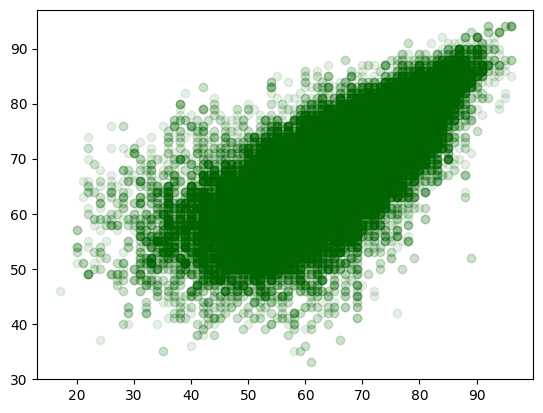

In [357]:
plt.scatter(X['reactions'], Y, color= 'darkgreen', label = 'Datos', alpha = .1)

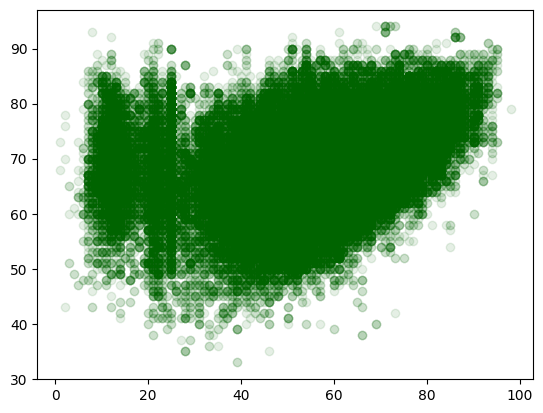

In [358]:
plt.scatter(X['heading_accuracy'], Y, color= 'darkgreen', label = 'Datos', alpha = .1)

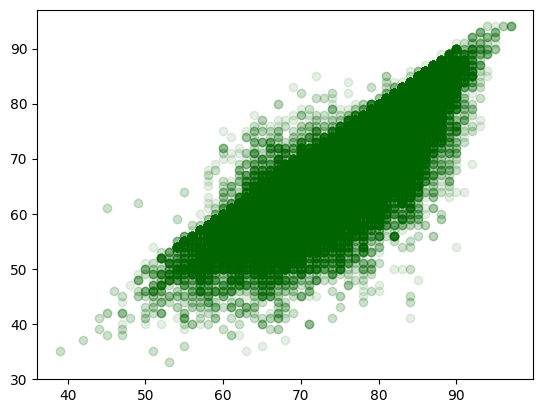

In [359]:
plt.scatter(X['potential'], Y, color= 'darkgreen', label = 'Datos', alpha = .1)

In [360]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size= 0.33, random_state = 324)

### Utilizar un escalado estándar 
Para que los datos de cada feature se acople a un rango y se eviten los sesgos de un feature con valores muy altos que puedan influir de más en el target

In [361]:
scale = preprocessing.StandardScaler()

### Entrenar con los datos escalados

In [362]:
scale.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [363]:
X_train = scale.transform(X_train)

In [364]:
# Imprimir los nuevos valores mínimo y máximo de las features de entrenamiento
X_train.min()

np.float64(-5.377337896778157)

In [365]:
X_train.max()

np.float64(4.9683467491419835)

### Creamos una instancia del modelo de Regresión Lineal de ScikitLearn

In [366]:
regresor = LinearRegression()

### Ajustando el  modelos a los datos 

In [367]:
regresor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Realizar una predicción usando el conjunto de datos de prueba (test set)

In [368]:
# Escalar los valores de prueba para que coincidan con los de entrenamiento
X_test = scale.transform(X_test)

In [369]:
# Hacer una predicción del valor de salida, pasandole los valores de prueba
y_prediccion = regresor.predict(X_test)

In [370]:
# Obteneer la diferencia que hay entre los valores de salida predichos contra los valores de salida reales 
y_result = y_prediccion - y_test
y_result

,overall_rating
35543,0.789178
28735,-2.172434
168029,1.574596
138117,0.462964
123316,0.218613
...,...
51151,1.980086
155333,-1.514635
118067,-0.222241
62126,2.382856


### Calcular la raiz cuadrada del error cuadratíco medio

In [371]:
RMSE = sqrt (mean_squared_error(y_true= y_test, y_pred= y_prediccion))
print (RMSE)

2.8712223699563046


### Mostrar la precisión que obtuvo el modelo al predecir con los valores de prueba

In [372]:
regresor.score(X_test, y_test)

0.833721691527504

#### Se realizó una reducción de feautures eliminando aquellas redundantes o altamente, las feautures iniciales obtenian una presición deo de .8412690897596594, mientras que las feautures mas simplificadas obtuvieron 0.833721691527504, mostrando una disminución mínima, para mi esto indica que es posible simplificar el modelo sin afectar significativamente su presición, lo cual mejora la interpretabilidad y eficiencia.

## Mostrar cual es el valor de cada w que se aplico a cada feature (w + X) para que al sumar todos los productos nos de el puntaje de cada jugador

In [377]:
regresor.coef_

array([[ 2.67395512,  0.46144521,  1.27619297,  1.24899346,  0.21527483,
         0.47709045,  0.31608382,  0.07616533,  0.08337234,  0.10019235,
         0.01967476,  2.03326717,  0.16928237,  0.3332576 , -0.06593655,
         0.78937066, -0.21343989,  0.34173155,  0.20686801, -0.08329121,
         0.08124338,  0.27303465,  0.70863761, -0.62073349,  2.53878476,
         0.44273006, -0.72652106,  0.82118639,  0.35949979]])

In [378]:
regresor.intercept_

array([68.63507038])